In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing   import  OneHotEncoder
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix




In [ ]:
data = pd.read_csv("/content/insurance_50k-1.csv")


# Basic Exploration

In [ ]:
df = pd.DataFrame(data)
df.sample(5)

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
27216,53,96.2,1.58,50.000000,False,Indore,business_owner,Low
6372,72,115.4,1.70,7.886034,False,Chandigarh,government_job,High
7280,70,90.3,1.74,8.176884,True,Bangalore,government_job,High
46351,68,57.1,1.78,11.842331,False,Chandigarh,government_job,High
30874,75,91.3,1.62,28.328769,False,Indore,unemployed,Medium


,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
29316,59,76.5,1.66,50.000000,True,Lucknow,unemployed,Medium
45855,40,106.7,1.80,19.554366,False,Lucknow,unemployed,Low
12944,21,69.3,1.88,18.984887,True,Mysore,unemployed,Medium
34093,60,85.6,1.69,3.413751,True,Mysore,student,High
16356,60,55.1,1.51,12.695759,True,Jaipur,retired,High


In [ ]:
df.shape

(50000, 8)

(50000, 8)

In [ ]:
df.isnull().sum()

,0
age,0
weight,0
height,0
income_lpa,0
smoker,0
city,0
occupation,0
insurance_premium_category,0


,0
age,0
weight,0
height,0
income_lpa,0
smoker,0
city,0
occupation,0
insurance_premium_category,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         50000 non-null  int64  
 1   weight                      50000 non-null  float64
 2   height                      50000 non-null  float64
 3   income_lpa                  50000 non-null  float64
 4   smoker                      50000 non-null  bool   
 5   city                        50000 non-null  object 
 6   occupation                  50000 non-null  object 
 7   insurance_premium_category  50000 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(3)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                     

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


,0
0,False
1,False
2,False
3,False
4,False
...,...
49995,False
49996,False
49997,False
49998,False


In [ ]:
df.describe()

,age,weight,height,income_lpa
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,49.463120,85.371958,1.700045,19.080854
std,16.042119,19.813505,0.115361,15.709949
min,18.000000,51.100000,1.500000,0.530000
25%,37.000000,68.200000,1.600000,6.472666
50%,51.000000,85.400000,1.700000,13.506139
75%,63.000000,102.500000,1.800000,28.223393
max,75.000000,119.800000,1.900000,50.000000


,age,weight,height,income_lpa
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,49.463120,85.371958,1.700045,19.080854
std,16.042119,19.813505,0.115361,15.709949
min,18.000000,51.100000,1.500000,0.530000
25%,37.000000,68.200000,1.600000,6.472666
50%,51.000000,85.400000,1.700000,13.506139
75%,63.000000,102.500000,1.800000,28.223393
max,75.000000,119.800000,1.900000,50.000000


# EDA

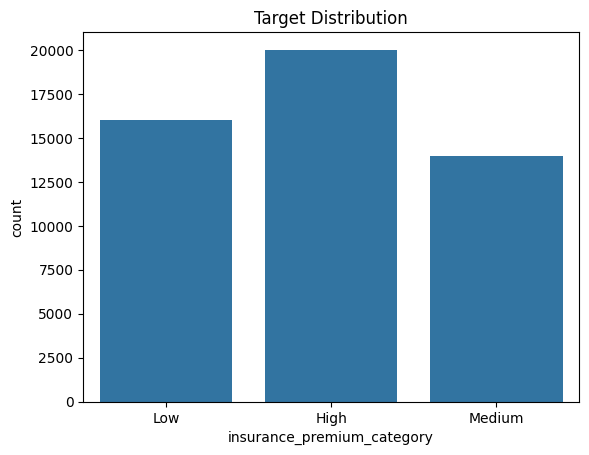

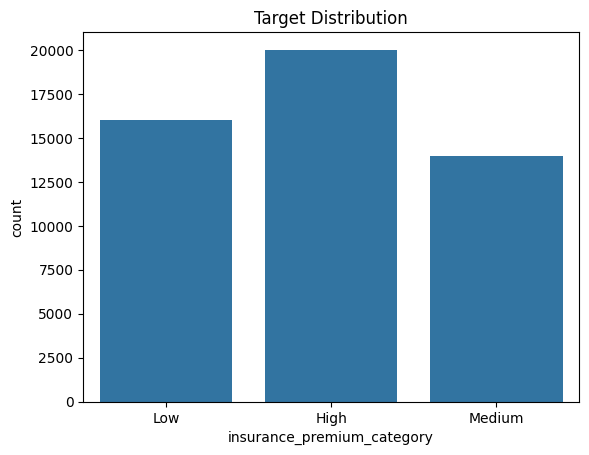

In [ ]:
#target Distribution
sns.countplot(x = 'insurance_premium_category', data = df)
plt.title("Target Distribution")
plt.show()


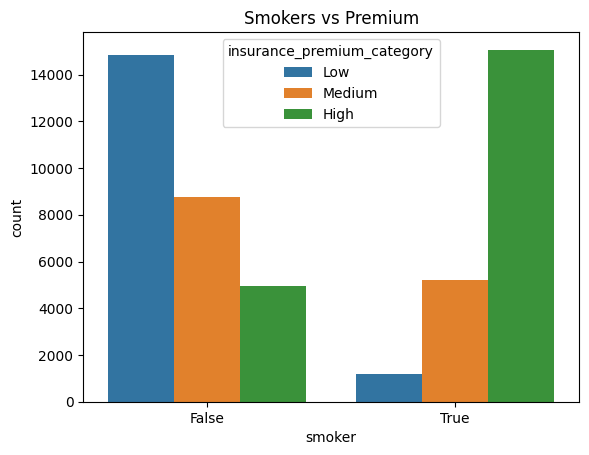

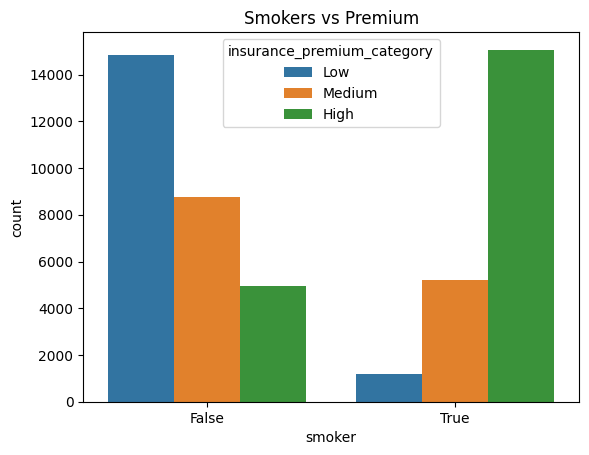

In [ ]:
#Smokers vs Premium
sns.countplot(x = 'smoker', hue = 'insurance_premium_category', data = df)
plt.title("Smokers vs Premium")
plt.show()

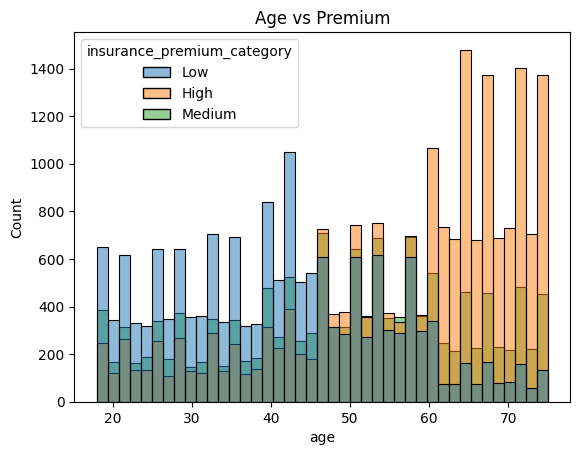

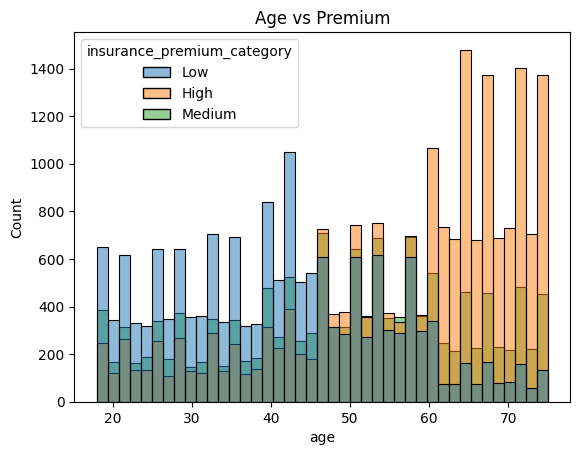

In [ ]:
sns.histplot(x = 'age', hue = 'insurance_premium_category', data = df)
plt.title("Age vs Premium")
plt.show()

#

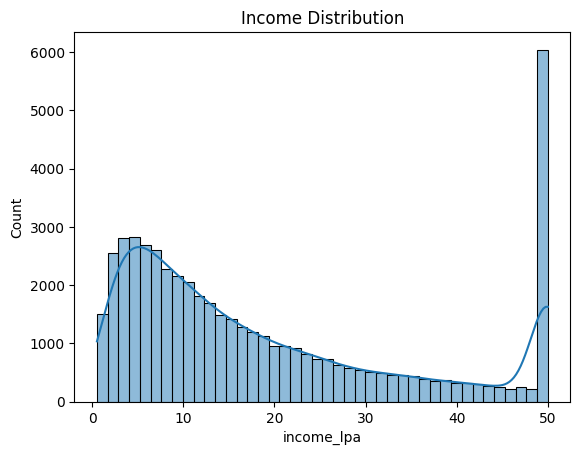

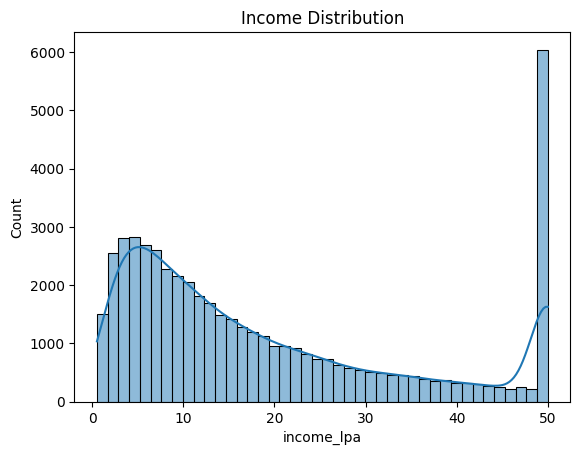

In [ ]:
sns.histplot(df['income_lpa'], kde = True)
plt.title("Income Distribution")
plt.show()


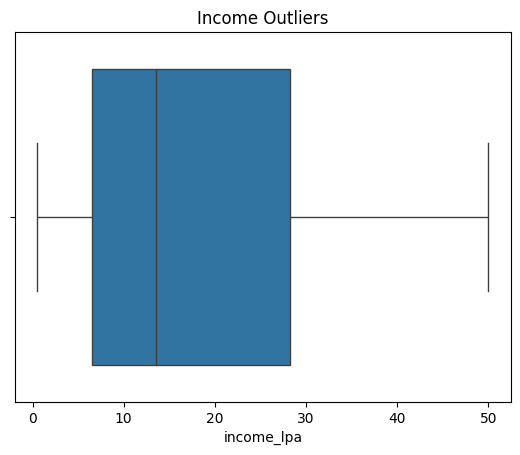

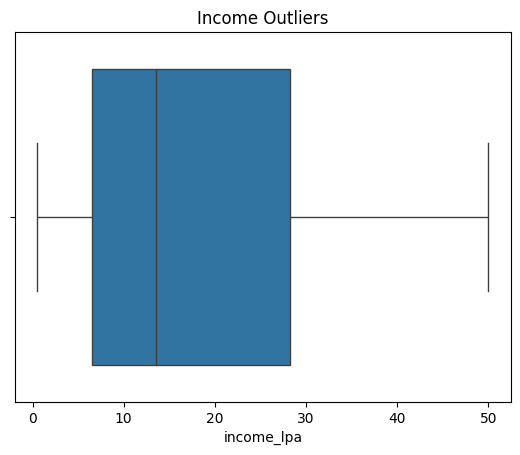

In [ ]:
#boxplot for outliers
sns.boxplot(x = df['income_lpa'])
plt.title("Income Outliers")
plt.show()

Automated exploratory Validation using ydata profiling

In [ ]:
# ydata_profiling ran only once
#!pip install ydata_profiling
#from ydata_profiling import ProfileReport
#prof = ProfileReport(df)
#prof.to_file(output_file='InsureEDA.html')

# Feature Engineering

In [ ]:
df['occupation'].unique()

array(['student', 'retired', 'government_job', 'business_owner',
       'unemployed', 'freelancer', 'private_job'], dtype=object)

array(['student', 'retired', 'government_job', 'business_owner',
       'unemployed', 'freelancer', 'private_job'], dtype=object)

In [ ]:
df_feat = df.copy()

In [ ]:
# Feature 1: BMI
df_feat["bmi"] = df_feat["weight"] / (df_feat["height"] ** 2)


In [ ]:
# Feature 2: Age Group
def age_group(age):
    if age < 25:
        return "young"
    elif age < 45:
        return "adult"
    elif age < 60:
        return "middle_aged"
    return "senior"


In [ ]:
df_feat["age_group"] = df_feat["age"].apply(age_group)

In [ ]:
# Feature 3: Lifestyle Risk
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30:
        return "high"
    elif row["smoker"] or row["bmi"] > 27:
        return "medium"
    else:
        return "low"

In [ ]:
df_feat["lifestyle_risk"] = df_feat.apply(lifestyle_risk, axis=1)

In [ ]:
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

In [ ]:
# Feature 4: City Tier
def city_tier(city):
    if city in tier_1_cities:
        return 1
    elif city in tier_2_cities:
        return 2
    else:
        return 3

In [ ]:
df_feat["city_tier"] = df_feat["city"].apply(city_tier)

In [ ]:
df_feat = df_feat.drop(columns=['age', 'weight', 'height', 'smoker', 'city'])[['income_lpa', 'occupation', 'bmi', 'age_group', 'lifestyle_risk', 'city_tier', 'insurance_premium_category']]


In [ ]:
df_feat.sample(5)

,income_lpa,occupation,bmi,age_group,lifestyle_risk,city_tier,insurance_premium_category
33132,10.081504,student,15.076698,middle_aged,low,2,Low
45786,5.948147,business_owner,20.286508,adult,medium,1,Medium
26220,50.000000,retired,32.855700,adult,high,1,Medium
34158,8.989793,private_job,20.342425,senior,medium,2,High
5302,22.178375,unemployed,40.900281,adult,medium,2,Low


,income_lpa,occupation,bmi,age_group,lifestyle_risk,city_tier,insurance_premium_category
27880,5.433000,business_owner,26.343895,senior,low,2,Medium
34838,38.111132,private_job,39.109092,adult,medium,2,Low
21846,39.898521,student,31.250000,middle_aged,medium,1,Low
16116,7.368180,freelancer,36.866801,adult,medium,2,Low
14532,18.124912,government_job,21.834579,senior,medium,1,High


EDA on new features

In [ ]:
'''from ydata_profiling import ProfileReport
prof = ProfileReport(df_feat)
prof.to_file(output_file='InsureEDANEWFeat.html')'''

"from ydata_profiling import ProfileReport\nprof = ProfileReport(df_feat)\nprof.to_file(output_file='InsureEDANEWFeat.html')"

"from ydata_profiling import ProfileReport\nprof = ProfileReport(df_feat)\nprof.to_file(output_file='InsureEDANEWFeat.html')"

# Preprocessing Pipeline

In [ ]:
# Select features and target
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]



In [ ]:
# Define categorical and numeric features
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]



In [ ]:
# Create column transformer for OHE
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


In [ ]:
# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1,stratify=y)

In [ ]:

# Random Forest Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

#  Hyperparameter Tuning Configurations
param_grid = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

# Randomized Search
# Define the hyperparameter search cross-validation space
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

#  Fit & Optimize the Model
print("Starting Hyperparameter Tuning...")
random_search.fit(X_train, y_train)

print("\n--- Tuning Optimization Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy Score: {random_search.best_score_:.4f}")




#  best estimator model from the grid search object
best_pipeline = random_search.best_estimator_




Starting Hyperparameter Tuning...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Tuning Optimization Complete ---
Best Parameters Found: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 20}
Best Cross-Validation Accuracy Score: 0.9320
Starting Hyperparameter Tuning...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

--- Tuning Optimization Complete ---
Best Parameters Found: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'log2', 'classifier__max_depth': 20}
Best Cross-Validation Accuracy Score: 0.9320


In [ ]:
# Predict
y_pred = best_pipeline.predict(X_test)
accuracy_score(y_test, y_pred)


0.9264

In [ ]:
X_test.sample(5)

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
36134,23.683172,middle_aged,medium,1,16.297323,government_job
35575,24.192841,middle_aged,low,2,20.421314,retired
11281,21.222808,adult,low,1,10.752100,freelancer
21286,32.256028,adult,high,3,50.000000,government_job
13423,32.534020,senior,high,2,14.150465,freelancer


,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
24451,31.675338,middle_aged,high,2,25.849930,retired
31754,20.234375,adult,low,2,10.835165,private_job
17075,26.328125,middle_aged,medium,2,7.528061,retired
15584,18.117284,senior,medium,2,31.231986,government_job
36492,34.370135,middle_aged,high,2,36.901509,freelancer


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.95      0.94      4002
         Low       0.94      0.93      0.93      3206
      Medium       0.90      0.89      0.89      2792

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000


Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.95      0.94      4002
         Low       0.94      0.93      0.93      3206
      Medium       0.90      0.89      0.89      2792

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



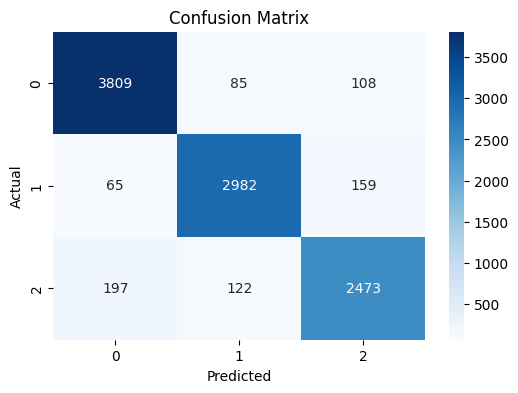

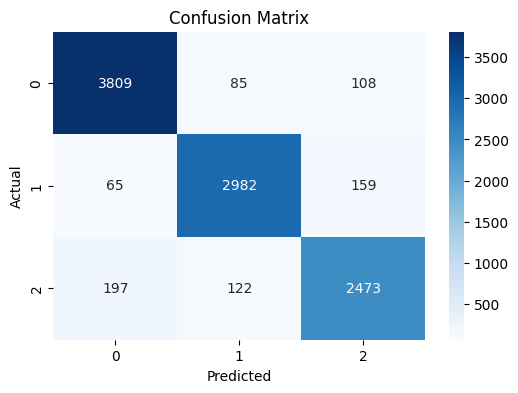

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score
cross_val_score(best_pipeline, X_train, y_train, cv=10, scoring='accuracy').mean()

np.float64(0.9326250000000001)

In [ ]:
import pickle

# Save the trained pipeline using pickle
pickle_model_path = "model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(best_pipeline, f)


In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.1.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.5.18.1.11.28
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.40.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.3.3
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.5.20
c